# Asymmetry, Example 3: time-translation symmetry in a Davies map

**Manuscript map.** Sec. III F, Fig. 7, Eqs. (65)-(67).

A four-spin transverse-field Ising model thermalizes under a Davies
generator. Because the generator commutes with Hamiltonian evolution,
operator space splits into Bohr-frequency modes. Populations form the
$\mu=0$ block; energy-basis coherences form the $\mu\ne0$ blocks.

We construct two isospectral initial states. A local-unitary search gives
the second state very small overlap with the slowest coherent mode while
retaining larger initial asymmetry. The resulting crossing is the
time-translation-symmetry Mpemba effect.

**Convention note.** The released simulation script sets a bath
temperature $T=0.1$ and passes $\beta=1/T=10$ to the Davies generator.
This notebook follows that executable convention. Set `BETA_BATH=0.1`
below to study the literal inverse-temperature value printed in the
figure caption.


In [1]:
import sys
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import scipy.linalg as la

_HERE = Path.cwd().resolve()
for _candidate in [_HERE, *_HERE.parents]:
    if (_candidate / "tools" / "notebook_utils.py").exists():
        _TOOLS_DIR = _candidate / "tools"
        break
else:
    raise RuntimeError(
        "Could not locate tools/notebook_utils.py from cwd or its parents."
    )
if str(_TOOLS_DIR) not in sys.path:
    sys.path.insert(0, str(_TOOLS_DIR))

import notebook_utils as nu

warnings.filterwarnings("ignore", category=RuntimeWarning)
np.set_printoptions(precision=5, suppress=True)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.figsize": (7.2, 4.2),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "font.size": 11,
})

BLUE = "#394F87"
ORANGE = "#E8792E"
GREEN = "#3A7D44"
PURPLE = "#7C4D9E"


## 1. TFIM and Davies spectrum

The released code represents spin operators as $s^\alpha=\sigma^\alpha/2$:

$$
H_s=-J\sum_{n=1}^{N_s-1}s_n^z s_{n+1}^z
    +h\sum_{n=1}^{N_s}s_n^x .
$$

The compact generator below is algebraically equivalent to summing the
rank-one Davies jump operators in the energy basis. Population rates obey
detailed balance, while each coherence is an independent complex
eigenmode.


In [2]:
N_SITES = 4
J = 1.0
H_FIELD = 1.0
BETA_BATH = 10.0
BETA_INITIAL = 1.0
NOISE_STRENGTH = 0.05

hamiltonian = nu.tfim_hamiltonian(
    N_SITES, J, H_FIELD, spin_half_operators=True
)
L, energies, energy_basis, pi = nu.davies_liouvillian(
    hamiltonian, BETA_BATH
)

eigenvalues, left_vectors = la.eig(L, left=True, right=False)
order = np.argsort(np.abs(eigenvalues.real))
eigenvalues = eigenvalues[order]
left_vectors = left_vectors[:, order]

print("Eight eigenvalues with real part closest to zero:")
print(eigenvalues[:8])
assert np.allclose(L @ nu.vec(pi), 0, atol=1e-10)


Eight eigenvalues with real part closest to zero:
[-0.     +0.j      -0.5324 -0.62774j -0.5324 +0.62774j -1.00377-0.j
 -1.06085+0.91859j -1.06085-0.91859j -1.59126+0.29086j -1.59126-0.29086j]


## 2. Initial state and fast local-unitary rotation

Following Eq. (66),

$$
\rho_1=\frac{\rho_{\rm Gibbs}(\beta_i)+\gamma X^\dagger X}
             {\mathcal N}.
$$

The noise matrix and seed match the released script. We identify the
first nonstationary complex mode and search over products of single-qubit
Haar unitaries. Among candidates with at most 5% of the original overlap,
we retain the most asymmetric state. This is a quiet, deterministic
version of the paper's Metropolis rotation.


In [3]:
rho_1 = nu.manuscript_noisy_gibbs_state(
    energies, BETA_INITIAL, NOISE_STRENGTH, seed=0
)

coherent_indices = []
for index, value in enumerate(eigenvalues):
    matrix = nu.unvec(left_vectors[:, index], 2**N_SITES)
    off_diagonal = matrix - np.diag(np.diag(matrix))
    if value.real < -1e-10 and la.norm(off_diagonal) > 1e-8:
        coherent_indices.append(index)

slow_index = coherent_indices[0]
slow_eigenvalue = eigenvalues[slow_index]
slow_left_mode = nu.unvec(
    left_vectors[:, slow_index], 2**N_SITES
)
slow_left_mode /= la.norm(slow_left_mode)

rho_2, rotation, diagnostics = nu.find_fast_asymmetric_state(
    rho_1,
    slow_left_mode,
    N_SITES,
    samples=12_000,
    cost_fraction=0.05,
    seed=15,
)

nu.validate_density(rho_1)
nu.validate_density(rho_2)
assert np.allclose(la.eigvalsh(rho_1), la.eigvalsh(rho_2))
print("Slow coherent eigenvalue:", slow_eigenvalue)
for key, value in diagnostics.items():
    print(f"{key:>20s}: {value:.6g}")


Slow coherent eigenvalue: (-0.5324043313333621-0.6277385326490519j)
     initial_overlap: 0.0140327
       final_overlap: 0.000469534
   initial_asymmetry: 0.26865
     final_asymmetry: 0.473243


## 3. Symmetry monotone and crossing

Time-translation twirling is dephasing in the energy eigenbasis:

$$
\mathcal G[\rho]=\operatorname{diag}(\rho).
$$

Therefore

$$
M[\rho(t)]
=S(\rho(t)\Vert\mathcal G[\rho(t)])
=S(\mathcal G[\rho(t)])-S(\rho(t)).
$$


In [4]:
times = np.linspace(0, 10, 1_001)
states_1 = nu.evolve_density(L, rho_1, times)
states_2 = nu.evolve_density(L, rho_2, times)

M_1 = np.array([
    nu.asymmetry_relative_entropy(state, nu.energy_dephase(state))
    for state in states_1
])
M_2 = np.array([
    nu.asymmetry_relative_entropy(state, nu.energy_dephase(state))
    for state in states_2
])
tau = nu.crossing_time(times, M_2, M_1)

print(f"Initial M: rho_1={M_1[0]:.4f}, rho_2={M_2[0]:.4f}")
print(f"Crossing time: {tau:.4f}")
assert M_2[0] > M_1[0]
assert np.isfinite(tau)


Initial M: rho_1=0.2687, rho_2=0.4732
Crossing time: 0.4334


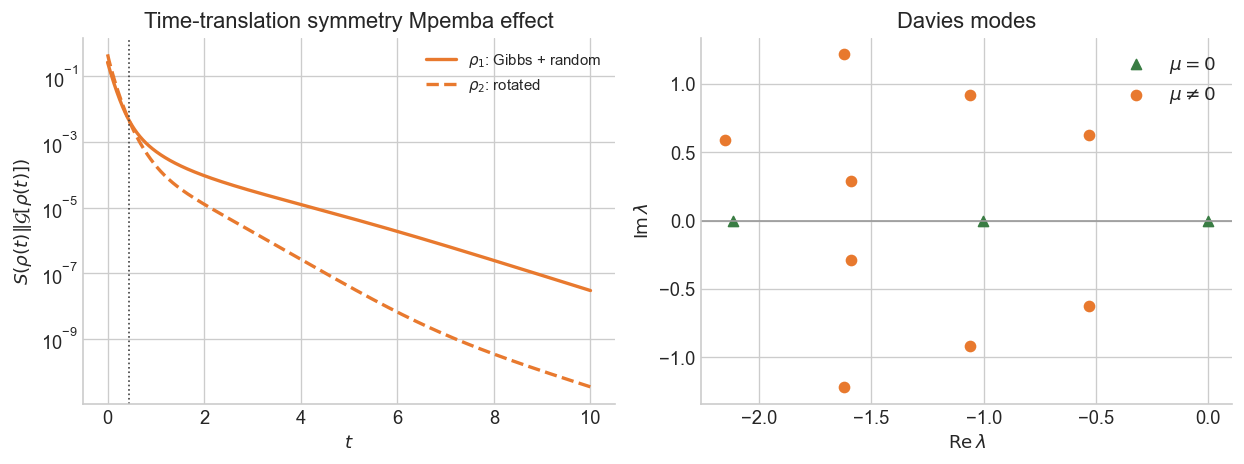

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4))
axes[0].semilogy(times, M_1, color=ORANGE, lw=2,
                label=r"$\rho_1$: Gibbs + random")
axes[0].semilogy(times, M_2, color=ORANGE, lw=2, ls="--",
                label=r"$\rho_2$: rotated")
axes[0].axvline(tau, color="0.25", ls=":", lw=1)
axes[0].set(xlabel=r"$t$", ylabel=r"$S(\rho(t)\Vert\mathcal{G}[\rho(t)])$",
            title="Time-translation symmetry Mpemba effect")
axes[0].legend(fontsize=9)

shown = eigenvalues[:12]
is_coherent = []
for index in range(min(12, len(eigenvalues))):
    matrix = nu.unvec(left_vectors[:, index], 2**N_SITES)
    is_coherent.append(
        la.norm(matrix - np.diag(np.diag(matrix))) > 1e-8
    )
is_coherent = np.asarray(is_coherent)
axes[1].scatter(shown.real[~is_coherent], shown.imag[~is_coherent],
                color=GREEN, marker="^", label=r"$\mu=0$")
axes[1].scatter(shown.real[is_coherent], shown.imag[is_coherent],
                color=ORANGE, label=r"$\mu\ne0$")
axes[1].axhline(0, color="0.6", lw=1)
axes[1].set(xlabel=r"$\operatorname{Re}\lambda$",
            ylabel=r"$\operatorname{Im}\lambda$",
            title="Davies modes")
axes[1].legend()
fig.tight_layout()
plt.show()


## 4. Petz-Renyi dependence

We repeat the crossing analysis for
$D_\alpha(\rho\Vert\mathcal G[\rho])$. A coarser time grid keeps this
diagnostic fast while preserving the trend.


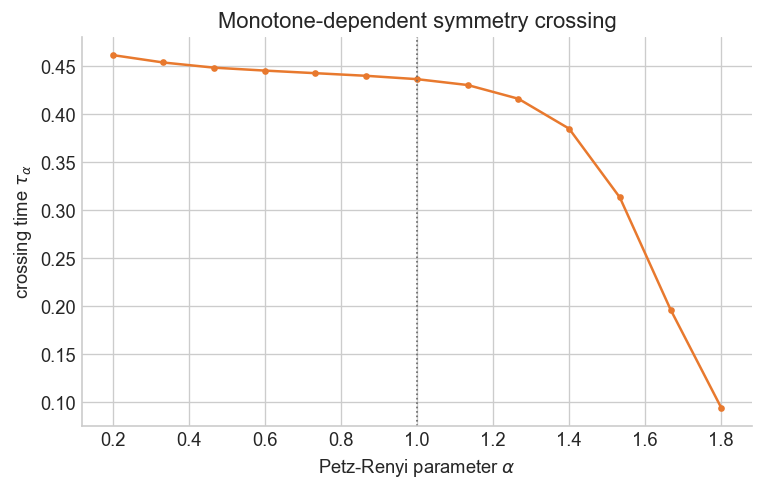

In [6]:
alphas = np.linspace(0.2, 1.8, 13)
sample = slice(None, None, 5)
sampled_times = times[sample]
crossing_times = []
for alpha in alphas:
    d1 = np.array([
        nu.petz_renyi(state, nu.energy_dephase(state), alpha)
        for state in states_1[sample]
    ])
    d2 = np.array([
        nu.petz_renyi(state, nu.energy_dephase(state), alpha)
        for state in states_2[sample]
    ])
    crossing_times.append(
        nu.crossing_time(sampled_times, d2, d1)
    )

fig, ax = plt.subplots()
ax.plot(alphas, crossing_times, marker="o", ms=3, color=ORANGE)
ax.axvline(1, color="0.4", ls=":", lw=1)
ax.set(xlabel=r"Petz-Renyi parameter $\alpha$",
       ylabel=r"crossing time $\tau_\alpha$",
       title="Monotone-dependent symmetry crossing")
plt.show()


## Takeaway

Only the nonzero Bohr-frequency blocks contribute to the asymmetry
monotone. The rotated state is isospectral with the original one and
initially more asymmetric, but its overlap with the slowest coherent
eigenmode is strongly suppressed. Its late-time decay is therefore set by
a faster coherent mode.
